## Set_Piece_Analysis_LaLiga_2015_16

In [8]:
!pip install mplsoccer statsbombpy -q

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mplsoccer import Pitch
from statsbombpy import sb

# Load La Liga 2015/2016
matches = sb.matches(competition_id=11, season_id=26)

# Load all events
all_events = []

for match_id in matches['match_id']:
    try:
        events = sb.events(match_id=match_id)
        all_events.append(events)
    except:
        pass

all_events = pd.concat(all_events, ignore_index=True)
print(f"Total events loaded: {len(all_events)}")

Total events loaded: 142957


In [9]:
# Filter set piece events
set_pieces = all_events[all_events['pass_type'].isin([
    'Corner', 'Free Kick', 'Throw-in'
])].copy()

print("Set piece types:")
print(set_pieces['pass_type'].value_counts())

print(f"\nTotal set pieces: {len(set_pieces)}")

# Filter Barcelona set pieces only
barca_set_pieces = set_pieces[set_pieces['team'] == 'Barcelona']
print(f"\nBarcelona set pieces: {len(barca_set_pieces)}")
print("\nBarcelona set piece breakdown:")
print(barca_set_pieces['pass_type'].value_counts())

Set piece types:
pass_type
Throw-in     1398
Free Kick    1072
Corner        373
Name: count, dtype: int64

Total set pieces: 2843

Barcelona set pieces: 1572

Barcelona set piece breakdown:
pass_type
Throw-in     724
Free Kick    611
Corner       237
Name: count, dtype: int64


In [10]:
# Filter Barcelona corners only
barca_corners = barca_set_pieces[barca_set_pieces['pass_type'] == 'Corner'].copy()

# Extract delivery locations and end locations
barca_corners['x'] = barca_corners['location'].apply(lambda loc: loc[0])
barca_corners['y'] = barca_corners['location'].apply(lambda loc: loc[1])
barca_corners['end_x'] = barca_corners['pass_end_location'].apply(lambda loc: loc[0])
barca_corners['end_y'] = barca_corners['pass_end_location'].apply(lambda loc: loc[1])

# Check delivery zones - where do corners land
print(f"Total Barcelona corners: {len(barca_corners)}")
print(f"\nCorner outcomes:")
print(barca_corners['pass_outcome'].value_counts())

# How many corners led directly to shots
print(f"\nCorners that were shot assists:")
print(barca_corners['pass_shot_assist'].value_counts())

# How many corners led to goals
print(f"\nCorners that were goal assists:")
print(barca_corners['pass_goal_assist'].value_counts())

Total Barcelona corners: 237

Corner outcomes:
pass_outcome
Incomplete    107
Unknown         3
Name: count, dtype: int64

Corners that were shot assists:
pass_shot_assist
True    30
Name: count, dtype: int64

Corners that were goal assists:
pass_goal_assist
True    4
Name: count, dtype: int64


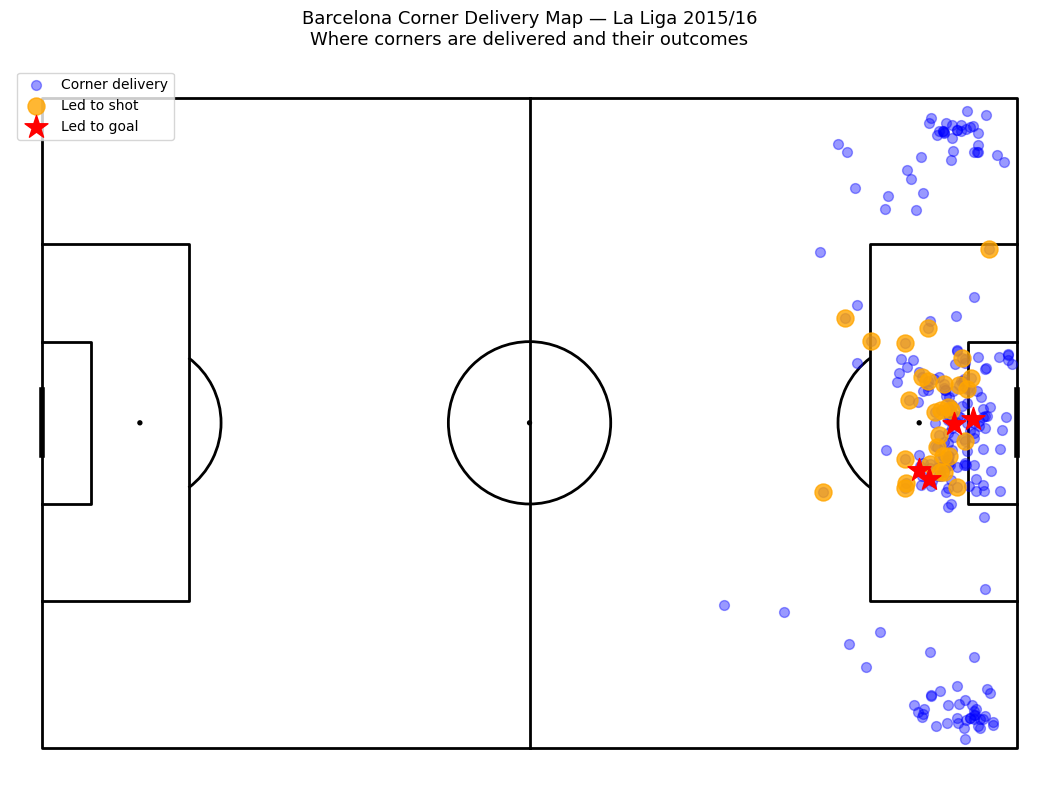

In [11]:
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = pitch.draw(figsize=(12, 8))

# Plot all corner deliveries
pitch.scatter(barca_corners['end_x'], barca_corners['end_y'],
              ax=ax, s=50, color='blue', alpha=0.4, label='Corner delivery')

# Highlight corners that led to shots
shot_assists = barca_corners[barca_corners['pass_shot_assist'] == True]
pitch.scatter(shot_assists['end_x'], shot_assists['end_y'],
              ax=ax, s=150, color='orange', alpha=0.8, label='Led to shot')

# Highlight corners that led to goals
goal_assists = barca_corners[barca_corners['pass_goal_assist'] == True]
pitch.scatter(goal_assists['end_x'], goal_assists['end_y'],
              ax=ax, s=300, color='red', marker='*', label='Led to goal')

ax.set_title('Barcelona Corner Delivery Map — La Liga 2015/16\nWhere corners are delivered and their outcomes',
             fontsize=13, pad=15)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# Who takes Barcelona's corners
print("Barcelona corner takers:")
print(barca_corners['player'].value_counts().head(5))

# Now find what happens after corners - get all events within 5 seconds of a corner
barca_corners['timestamp'] = pd.to_datetime(barca_corners['timestamp'])
all_events['timestamp'] = pd.to_datetime(all_events['timestamp'])

# Find shots that came from corners
corner_shots = all_events[
    (all_events['type'] == 'Shot') &
    (all_events['team'] == 'Barcelona') &
    (all_events['shot_type'] == 'Corner')
]

print(f"\nShots from corners: {len(corner_shots)}")
print(f"\nWho scored from corners:")
print(corner_shots[corner_shots['shot_outcome'] == 'Goal'][['player', 'shot_statsbomb_xg']])
print(all_events[all_events['type'] == 'Shot']['shot_type'].value_counts())

Barcelona corner takers:
player
Ivan Rakitić                       84
Xavier Hernández Creus             78
Lionel Andrés Messi Cuccittini     33
Neymar da Silva Santos Junior      25
Pedro Eliezer Rodríguez Ledesma     5
Name: count, dtype: int64


In [ ]:
# Split corners by left and right side
left_corners = barca_corners[barca_corners['y'] > 40]
right_corners = barca_corners[barca_corners['y'] <= 40]

pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, axes = pitch.draw(ncols=2, figsize=(16, 8))

# Left side corners
pitch.kdeplot(left_corners['end_x'], left_corners['end_y'],
              ax=axes[0], fill=True, cmap='Reds', levels=10, alpha=0.7)
axes[0].set_title(f'Left side corners ({len(left_corners)} corners)', fontsize=12)

# Right side corners
pitch.kdeplot(right_corners['end_x'], right_corners['end_y'],
              ax=axes[1], fill=True, cmap='Blues', levels=10, alpha=0.7)
axes[1].set_title(f'Right side corners ({len(right_corners)} corners)', fontsize=12)

plt.suptitle('Barcelona Corner Delivery Zones — Left vs Right Side\nLa Liga 2015/16',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Barcelona played 237 corners in La Liga 2015/16, with only 4 leading directly to goals — a conversion rate of 1.7%. This is low but makes complete sense for this Barcelona side who were far more dangerous in open play with Messi, Suarez, and Neymar. From the left side they delivered 125 corners, mostly direct and concentrated into the inner box — their most dangerous delivery zone. From the right side they played 112 corners with less concentration and more short corners to the player beside the flag, using the set piece as a way to create open play rather than a direct goal threat. This shows that Barcelona's set piece strategy was not purely about scoring from corners — it was about using them as another way to control the game and get into their preferred open play situations where they were almost unbeatable.